# Box and mask detectors, from a notebook

`skop.ops.detect` finds objects; `skop.ops.mask` draws one inside each box it is
given. There are two ops on each side -- `fastsam` or `object_aware_yolo`, then
`mobilesam_masks` or `microsam_masks` -- so there are four segmenters here, and
this notebook runs all four and plots each.

## Setup

Two environments are in play. The one this notebook runs in -- the *host* --
holds only what the notebook imports: a kernel, matplotlib, scikit-image for
its sample images, and tnia-python for the overlay helpers. The ops run in
*their own* environments, one per `env` id, which skop builds on first use. The
four here reach `pytorch` and `segment-everything`, neither of which belongs in
the host.

Those built environments live **outside the checkout**, in appose's shared
directory -- `~/.local/share/appose/skop-<env-id>` on Linux -- so several
projects share one copy and nothing multi-gigabyte lands in the repo. What is
in the checkout is `envs/<env-id>/pixi.toml`: the recipe, not the environment.

Build the host whichever way suits you, from the checkout root:

```sh
cd pixi/examples && pixi run register-kernel    # pixi
uv sync                                         # uv
```

Or by hand, into a conda env or venv you already have:

```sh
pip install -e .    # scikit-ops is not on PyPI yet, so editable from source
pip install jupyterlab matplotlib scikit-image "tnia-python[plotting]"
```

**The first run builds the op environments** -- two PyTorch stacks, several
gigabytes -- and each model then downloads its weights. Build phases print as
they happen, so a long silence means something is wrong rather than slow. See
[notebooks/README.md](../README.md) if one fails.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

# Sample images, shipped with scikit-image, no download. `cat` and `astronaut`
# are photographs, which is what these models were trained on; `coins` and
# `human_mitosis` are the crowded cases, where masks overlap and the choice of
# projection below starts to matter.
from skimage.data import astronaut, cat, coins, human_mitosis

import skop
from skop import masks
from skop.ops.detect import fastsam, object_aware_yolo
from skop.ops.mask import microsam_masks, mobilesam_masks

# Both modules name their checkpoint enum PretrainedModel, and they are
# different enums -- FastSAM's two published weights, and micro_sam's four
# finetunings. Aliased rather than imported bare so neither shadows the other.
from skop.ops.detect.fastsam import PretrainedModel as FastSAMModel
from skop.ops.mask.microsam import PretrainedModel as MicroSAMModel

from tnia.plotting.plt_helper import draw_boxes, mask_overlay, mask_outline_overlay

## Load the image

Any of the sample images imported above. `cat` is the default: one object, a
photograph, but a cat has eyes.  Can we detect both the cat and the eyes. 

(300, 451, 3) uint8, range 0-231


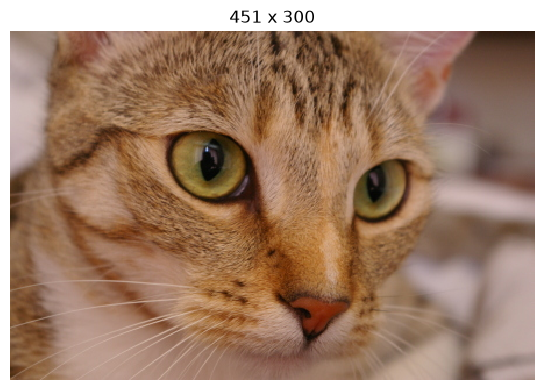

In [2]:
image = cat()  # or coins(), human_mitosis(), astronaut()

print(f"{image.shape} {image.dtype}, range {image.min()}-{image.max()}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
ax.set_title(f"{image.shape[1]} x {image.shape[0]}")
ax.axis("off")
fig.tight_layout()

## The runner

A `Runner` is a session rather than a call: it builds environments, starts a
worker for each, and keeps them warm between runs. So one lives for the life of
the notebook, and the last cell closes it -- a worker is a process, and a kernel
that dies without closing leaves them behind.

`subscribe_build_progress` reports environment builds, and `on_progress` reports
the op itself. A panel has a status bar for both; a notebook has `print`, and
without it a four-minute SAM run is indistinguishable from a hung one.

In [3]:
runner = skop.Runner()

_phase = None
_build_log = []


def on_build(title, current, maximum):
    """Print each build phase once, rather than on every tick of it."""
    global _phase
    if title != _phase:
        _phase = title
        print(f"  [build] {title}")


def on_build_error(chunk):
    """Buffer pixi's stderr rather than printing it.

    This is the stream, not a failure report: pixi writes its ordinary status
    there, and a progress subscriber puts it in -vv, so printing it live would
    bury everything else. Buffered, it is exactly what you want when a build
    does fail -- an unsatisfiable solve says so here and nowhere else, and
    without this a failure reads only as "pixi build failed".
    """
    _build_log.append(chunk)


runner.subscribe_build_progress(on_build)
runner.subscribe_build_error(on_build_error)


## Stage one: the detectors

Both detectors take the same two settings that matter, and both already default
to these values. They are written out because they are the ones worth turning.

- `conf` -- confidence threshold. Lower finds more, and more spuriously.
- `iou` -- NMS threshold. Two detections overlapping by more than this are
  treated as one object. At 0.9 almost nothing is merged, which is what you
  want for objects that touch.

`fastsam` also picks a checkpoint: `small` is 24 MB, `large` is better and
slower. Small is enough for one cat. `object_aware_yolo` has no such choice --
it is one fine-tuned YOLO and nothing else.

A detector that fails is recorded and skipped rather than stopping the
notebook, so one working environment is still worth running.

In [4]:
CONF = 0.4
IOU = 0.9

DETECTORS = {
    "fastsam": (fastsam, {"model": FastSAMModel.small, "conf": CONF, "iou": IOU}),
    "object_aware_yolo": (object_aware_yolo, {"conf": CONF, "iou": IOU}),
}

detections = {}

on_progress=lambda event: print(f"  {event.message}")

for name, (op, args) in DETECTORS.items():
    print(f"\n{name}")
    try:
        result = runner.run(
            op, on_progress=on_progress, image=image, **args
        )
        detections[name] = result.boxes

    except Exception as exc:  # noqa: BLE001 -- a notebook, not a test
        print(f"  failed: {type(exc).__name__}: {exc}")



fastsam
  None
  Loading FastSAM-s.pt
  Detecting objects
  Found 8 objects
  None

object_aware_yolo
  None
  Loading the object-aware model
  Detecting objects
  Found 6 objects
  None


### Drawing them

skop states boxes as `(N, 4)` rows of `[min_y, min_x, max_y, max_x]` -- see
`skop.boxes` -- which is `regionprops`' order and numpy's indexing order.
`draw_boxes` takes that directly, so there is no conversion here at all.

That helper lives in tnia-python rather than in skop, deliberately: it takes a
plain numpy array and knows nothing about skop, which keeps it useful for a
`regionprops` result or a bare YOLO one, and keeps the dependency pointing one
way. See [design 0012](../../docs/design/0012-notebook-rendering.md).

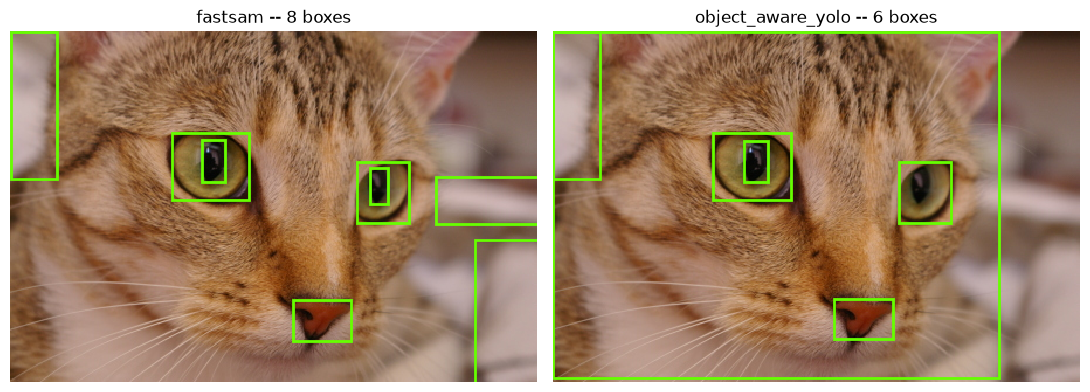

In [5]:
fig, axes = plt.subplots(1, max(len(detections), 1), figsize=(11, 4), squeeze=False)
for ax, (name, found) in zip(axes.flat, detections.items()):
    ax.imshow(image)
    draw_boxes(ax, found)
    ax.set_title(f"{name} -- {len(found)} boxes")
    ax.axis("off")
fig.tight_layout()

## Stage two: the mask detectors

A mask detector is *told* where to look -- that is what separates it from a
segmenter, which decides for itself and returns a label image. Each takes the
boxes from stage one and draws one mask inside each.

`microsam_masks` picks a finetuned checkpoint, and its default,
`light_microscopy`, is the wrong one here: this is a photograph of a cat.
`natural_image` is plain Segment Anything, unfinetuned -- the baseline the
others are finetuned away from, and the only sensible choice on this image.
That the default is wrong here is not a bug; it says who the op is for.

`mobilesam_masks` takes only `batch_size`, which trades GPU memory against the
number of decoder calls and changes nothing about the result, so it keeps its
default.

Note that N out need not equal N in: SAM returns an empty prediction for a box
it cannot make sense of, and both ops drop those. That is why `Masks` carries
the surviving prompts alongside the masks, and why the boxes drawn below come
from the *result* rather than from stage one.

In [6]:
MASKERS = {
    "mobilesam": (mobilesam_masks, {}),
    "microsam": (microsam_masks, {"model": MicroSAMModel.natural_image}),
}

results = {}
for det_name, det_boxes in detections.items():
    for mask_name, (op, args) in MASKERS.items():
        print(f"\n{det_name} -> {mask_name}")
        if len(det_boxes) == 0:
            print("  no boxes to segment")
            continue
        try:

            results[(det_name, mask_name)] = runner.run(
                op, on_progress=on_progress, image=image, boxes=det_boxes, **args
            ) 
            
            
            #run(
            #    op, image=image, boxes=det_boxes, **args
            #)
        except Exception as exc:  # noqa: BLE001 -- a notebook, not a test
            print(f"  failed: {type(exc).__name__}: {exc}")


fastsam -> mobilesam
  None
  Loading MobileSAMv2
  Encoding the image
  Segmenting objects 1-8 of 8
  Segmented 8 of 8 objects
  None

fastsam -> microsam
  None
  Loading vit_b
  Computing image embeddings
  Segmenting object 1 of 8
  Segmenting object 2 of 8
  Segmenting object 3 of 8
  Segmenting object 4 of 8
  Segmenting object 5 of 8
  Segmenting object 6 of 8
  Segmenting object 7 of 8
  Segmenting object 8 of 8
  Segmented 8 of 8 objects
  None

object_aware_yolo -> mobilesam
  None
  Loading MobileSAMv2
  Encoding the image
  Segmenting objects 1-6 of 6
  Segmented 6 of 6 objects
  None

object_aware_yolo -> microsam
  None
  Loading vit_b
  Computing image embeddings
  Segmenting object 1 of 6
  Segmenting object 2 of 6
  Segmenting object 3 of 6
  Segmenting object 4 of 6
  Segmenting object 5 of 6
  Segmenting object 6 of 6
  Segmented 6 of 6 objects
  None


### Drawing them

The result is `(N, Y, X)`, one plane per object, and the planes are allowed to
overlap -- a cat and the cushion under it, one coin behind another. Nothing
displays that directly, so it has to be projected, and `skop.masks` holds the
projections: `to_labels_2d` flattens to a single label image, `to_labels_3d`
gives every mask its own plane.

Flattening is lossy exactly where masks overlap, and `strategy` decides what it
loses. Sorted largest-first with `order_by_area`, `"min"` gives a contested
pixel to the largest object -- so an object wholly inside another vanishes --
and `"max"` gives it to the smallest, so every mask appears somewhere. With one
cat this cannot matter. It is written out anyway, because on anything with real
overlap it is the difference between seeing the small objects and not.

`mask_outline_overlay` then draws instance boundaries onto the RGB image.
Outlines rather than filled masks on purpose: `mask_overlay`, the other helper
in that module, paints hues into a value channel and greyscales the photograph
to do it -- which throws away most of what this particular image is.

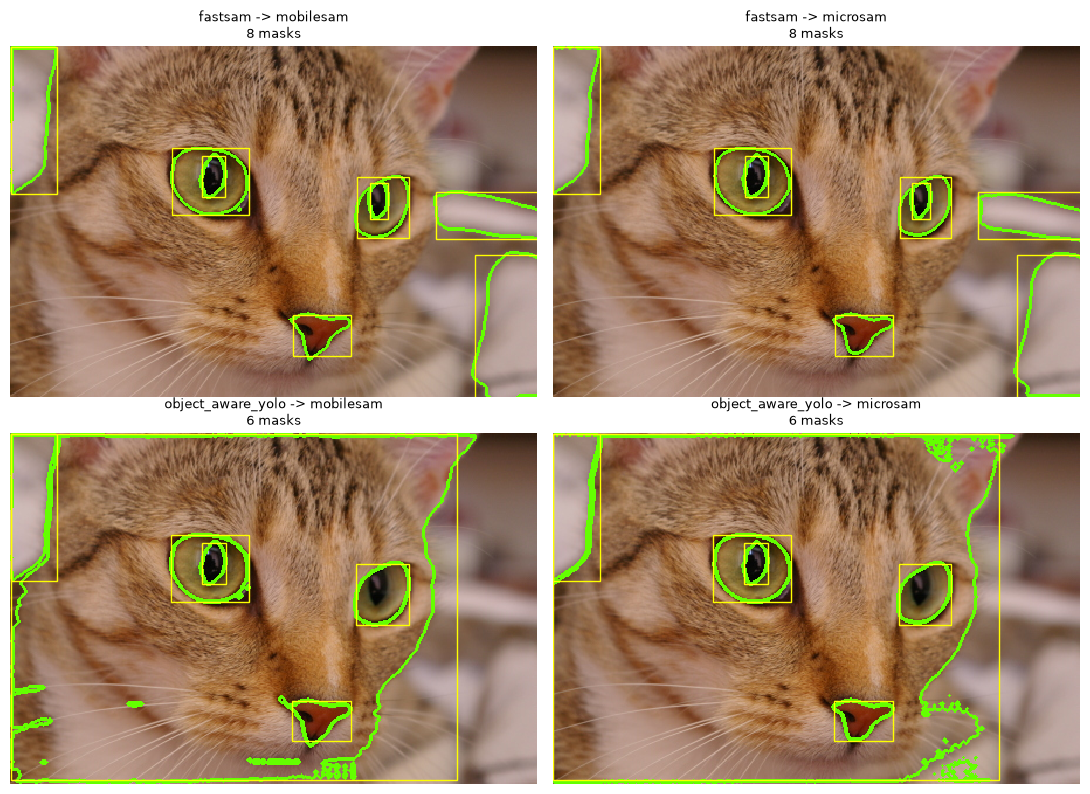

In [7]:
STRATEGY = "max"

fig, axes = plt.subplots(len(DETECTORS), len(MASKERS), figsize=(11, 8), squeeze=False)
for row, det_name in enumerate(DETECTORS):
    for col, mask_name in enumerate(MASKERS):
        ax = axes[row][col]
        ax.axis("off")

        found = results.get((det_name, mask_name))
        if found is None:
            ax.set_title(f"{det_name} -> {mask_name}\ndid not run", fontsize=9)
            continue

        # Largest first, which is what gives STRATEGY its meaning.
        order = masks.order_by_area(found.masks)
        labels = masks.to_labels_2d(found.masks[order], STRATEGY)

        ax.imshow(mask_outline_overlay(image, labels, color=(100, 255, 0), thickness=2))
        # Thin and yellow, so the prompts stay legible against the outlines.
        draw_boxes(ax, found.boxes, color=(1.0, 1.0, 0.0), linewidth=1)
        ax.set_title(
            f"{det_name} -> {mask_name}\n{len(found.masks)} masks", fontsize=9
        )

fig.tight_layout()

### The same masks, filled rather than outlined

`mask_overlay` is the other helper in that module, and it makes the opposite
trade: the photograph goes to greyscale and becomes the value channel, and each
label gets its own hue painted over it. Colour that was the cat's is spent
instead on saying which mask is which.

On one cat that is a poor bargain -- the outlines above show more. It is the
right picture the moment there are many objects and the question is where one
ends and the next begins, which is what it was written for in Cellpose. Both
views are here because neither is the default answer.

Same projection either way: `order_by_area` then `to_labels_2d`, since both
helpers take a label image rather than the stack.

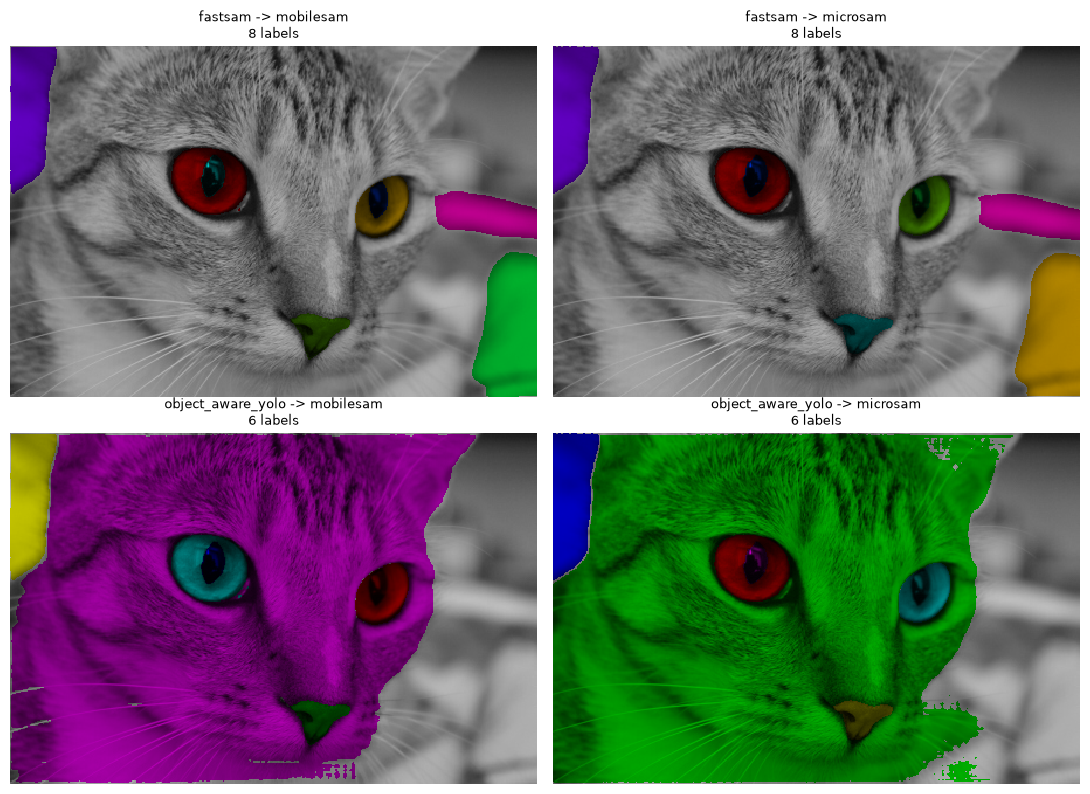

In [8]:
fig, axes = plt.subplots(len(DETECTORS), len(MASKERS), figsize=(11, 8), squeeze=False)
for row, det_name in enumerate(DETECTORS):
    for col, mask_name in enumerate(MASKERS):
        ax = axes[row][col]
        ax.axis("off")

        found = results.get((det_name, mask_name))
        if found is None:
            ax.set_title(f"{det_name} -> {mask_name}\ndid not run", fontsize=9)
            continue

        order = masks.order_by_area(found.masks)
        labels = masks.to_labels_2d(found.masks[order], STRATEGY)

        # Greyscales the image itself and paints a hue per label over it, so
        # no boxes on top -- they would be a third thing competing for the
        # same picture.
        ax.imshow(mask_overlay(image, labels))
        ax.set_title(
            f"{det_name} -> {mask_name}\n{labels.max()} labels", fontsize=9
        )

fig.tight_layout()

## Close the runner

Each environment that ran holds a worker process. Closing is not optional
housekeeping -- a kernel restarted without it leaves them running.

In [9]:
runner.close()

## What this leaves open

- **Four combinations is a survey now and will not be one later.** With tens of
  ops on each side, a notebook picks a pair and justifies the pick. Nothing here
  helps with that choice; comparing them needs per-object scores, which is
  [`docs/spec/per-object-features.md`](../../docs/spec/per-object-features.md)
  and does not exist yet.
- **The rendering helpers are tnia-python's, called by hand.** skop-napari maps
  a `Role` to a layer type in about twenty lines (`skop_napari/_roles.py`); this
  notebook does the equivalent inline and by eye. Whether that becomes a real
  matplotlib front end is [design 0012](../../docs/design/0012-notebook-rendering.md).
- **`STRATEGY` is invisible on one cat.** The flattening choice needs an image
  with genuine overlap before it can be shown to matter, which argues for a
  second notebook on something crowded rather than more text in this one.